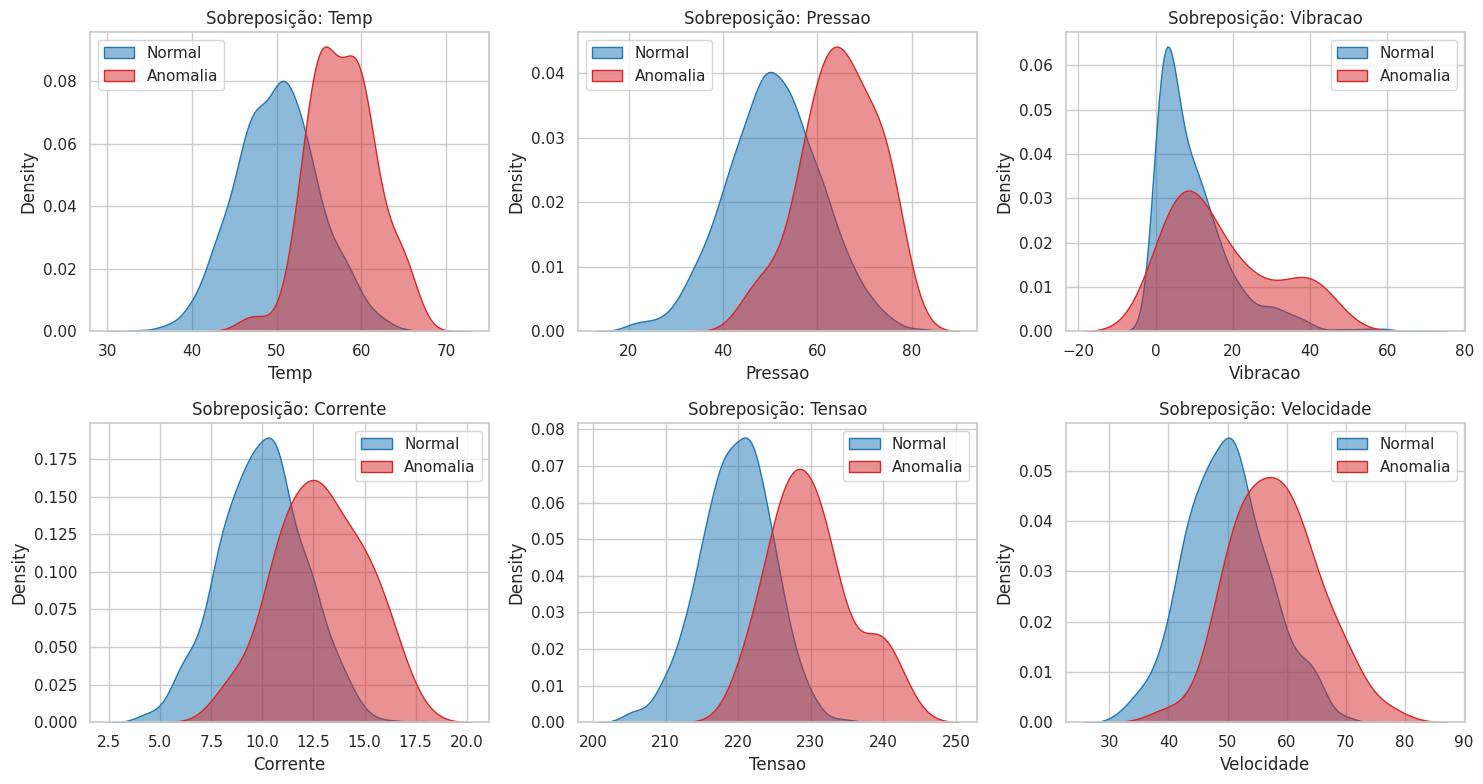


--- Iniciando Comparativo: IF vs Ensemble Robusto ---
Ruído (%)  F1 (IF)  F1 (Ensemble)  Recall (Ensemble)  Precision (Ensemble)
       0% 0.384615       0.545455           0.800000              0.413793
       5% 0.518519       0.565217           0.866667              0.419355
      10% 0.444444       0.636364           0.933333              0.482759


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.preprocessing import RobustScaler
from imblearn.ensemble import BalancedRandomForestClassifier # Requer: pip install imbalanced-learn

# --- 1. Geração de Dados (Seu padrão original) ---
def generate_subtle_data(n_normal=1000, n_anom=50):
    np.random.seed(42)
    nomes_sensores = ['Temp', 'Pressao', 'Vibracao', 'Corrente', 'Tensao', 'Velocidade']

    X_normal = np.column_stack([
        np.random.normal(50, 5, n_normal), np.random.normal(50, 10, n_normal),
        np.random.exponential(10, n_normal), np.random.normal(10, 2, n_normal),
        np.random.normal(220, 5, n_normal), np.random.poisson(50, n_normal)
    ])

    X_anom = np.column_stack([
        np.random.normal(58, 4, n_anom), np.random.normal(65, 8, n_anom),
        np.random.exponential(18, n_anom), np.random.normal(13, 2, n_anom),
        np.random.normal(230, 5, n_anom), np.random.poisson(60, n_anom)
    ])

    X = np.vstack((X_normal, X_anom))
    y = np.concatenate([np.zeros(n_normal), np.ones(n_anom)])
    return pd.DataFrame(X, columns=nomes_sensores), y

def apply_noise(df, level):
    if level == 0: return df.values
    noise = np.random.normal(0, df.std() * level * 2.5, df.shape)
    return df.values + noise

# --- 2. Visualização ---
def plot_distributions(df, y):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(15, 8))
    for i, col in enumerate(df.columns):
        plt.subplot(2, 3, i+1)
        sns.kdeplot(df[y==0][col], label='Normal', fill=True, color='#1f77b4', alpha=0.5)
        sns.kdeplot(df[y==1][col], label='Anomalia', fill=True, color='#d62728', alpha=0.5)
        plt.title(f'Sobreposição: {col}')
        plt.legend()
    plt.tight_layout()
    plt.show()

# --- 3. Execução do Ensemble ---
df_sensores, y = generate_subtle_data()
plot_distributions(df_sensores, y)

results = []
print("\n--- Iniciando Comparativo: IF vs Ensemble Robusto ---")

for level in [0.0, 0.05, 0.10]:
    X_noisy = apply_noise(df_sensores, level)
    # Split Estratificado para garantir anomalias no treino e teste
    X_train, X_test, y_train, y_test = train_test_split(X_noisy, y, test_size=0.3, stratify=y, random_state=42)

    # Escalonamento Robusto (Melhor para lidar com o ruído de 10%)
    scaler = RobustScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_test_s = scaler.transform(X_test)

    # MODELO 1: Isolation Forest (Baseline)
    contamination = len(y[y==1])/len(y)
    if_model = IsolationForest(contamination=contamination, random_state=42)
    if_model.fit(X_train_s)
    y_pred_if = np.where(if_model.predict(X_test_s) == -1, 1, 0)

    # MODELO 2: Balanced Random Forest (Especialista em desbalanceamento)
    brf_model = BalancedRandomForestClassifier(n_estimators=100, sampling_strategy='all', replacement=True, random_state=42)
    brf_model.fit(X_train_s, y_train)
    y_pred_brf = brf_model.predict(X_test_s)

    # ENSEMBLE: Votação de União (Prioriza Recall em cenários críticos)
    # Se qualquer um dos modelos detectar anomalia, classificamos como 1
    y_ensemble = np.where((y_pred_if + y_pred_brf) >= 1, 1, 0)

    results.append({
        "Ruído (%)": f"{int(level*100)}%",
        "F1 (IF)": f1_score(y_test, y_pred_if),
        "F1 (Ensemble)": f1_score(y_test, y_ensemble),
        "Recall (Ensemble)": recall_score(y_test, y_ensemble),
        "Precision (Ensemble)": precision_score(y_test, y_ensemble)
    })

# Exibição dos resultados
df_res = pd.DataFrame(results)
print(df_res.to_string(index=False))